### Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
BASE_DIR = Path().resolve().parent   
DATA_DIR = BASE_DIR / "data"

In [2]:
def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)
        
def show_full_fixed(df, col_width="500px"):
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
    ):
        display(
            df.style.set_table_styles([
                {"selector": "table", "props": [("table-layout", "fixed"), ("width", "100%")]},
                {"selector": "th, td", "props": [
                    ("min-width", col_width),
                    ("max-width", col_width),
                    ("white-space", "pre-wrap"),   # ✅ 换行显示
                    ("word-wrap", "break-word"),
                    ("overflow-wrap", "break-word"),
                    ("overflow", "visible")        # ✅ 不隐藏
                ]},
            ])
        )

### Read data 

In [4]:
df = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
print(df.shape)
cols = ['url', 'date', 'language', 'title', 'text']
print(cols)

(199989, 5)
['url', 'date', 'language', 'title', 'text']


### basic sanity checks

In [5]:
# --- basic sanity checks ---
s = df["text"].fillna("").astype(str)
t = df["title"].fillna("").astype(str)

print("N:", len(s))
print("Empty ratio:", (s.str.strip().eq("")).mean())
print("Duplicate text ratio:", (s.duplicated()).mean())
print("Duplicate title ratio:", (t.duplicated()).mean())
print("Length describe:\n", s.str.len().describe(percentiles=[.01,.05,.1,.85,.9,.95,.99]))

N: 199989
Empty ratio: 0.0
Duplicate text ratio: 0.002470135857472161
Duplicate title ratio: 0.1784298136397502
Length describe:
 count    199989.000000
mean       9098.766462
std        7264.733714
min          21.000000
1%          867.000000
5%         1466.400000
10%        3412.000000
50%        7622.000000
85%       13990.000000
90%       15766.000000
95%       19415.600000
99%       33832.040000
max      580772.000000
Name: text, dtype: float64


In [32]:
df.isna().sum()

url         0
date        0
language    0
title       0
text        0
dtype: int64

#### De duplicated text

In [6]:
df1 = df.drop_duplicates(subset=['text'], keep='first')

#### De duplicated title

In [8]:
print("Num pf docs of Duplicate titles:", df1["title"].duplicated().sum())

Num pf docs of Duplicate titles: 35190


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    ngram_range=(1,2)
)

dup_titles = df1[df1["title"].duplicated(keep=False)]

results = []

for title, grp in dup_titles.groupby("title"):
    texts = grp["text"].astype(str).tolist()
    if len(texts) < 2:
        continue
        
    X = vectorizer.fit_transform(texts)
    
    centroid = np.asarray(X.mean(axis=0))   # ← 修复
    
    sims = cosine_similarity(X, centroid)
    
    results.append({
        "title": title,
        "n_docs": len(texts),
        "mean_sim_to_centroid": float(np.mean(sims)),
        "min_sim_to_centroid": float(np.min(sims)),
        "std_sim": float(np.std(sims))
    })

sim_summary = pd.DataFrame(results).sort_values("mean_sim_to_centroid", ascending=False)

0.50    0.884232
0.70    0.941199
0.80    0.969342
0.90    0.989323
0.95    0.996699
0.99    0.999617
Name: mean_sim_to_centroid, dtype: float64


<Axes: >

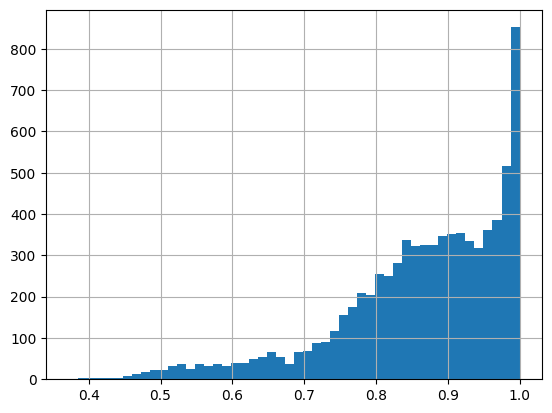

In [11]:
print(sim_summary["mean_sim_to_centroid"].quantile([.5, .7, .8, .9, .95, .99]))
sim_summary["mean_sim_to_centroid"].hist(bins=50)

In [16]:
def inspect_same_title(title, n_chars=5000):
    grp = df1[df1["title"] == title]
    print("="*80)
    print("TITLE:", title)
    print("Docs:", len(grp))
    print("="*80)
    
    for i, (_, r) in enumerate(grp.iterrows(), 1):
        print(f"\n--- Doc {i} | date={r['date']} | url={r['url'][:80]}")
        print("-"*60)
        print(str(r["text"])[:n_chars])

low_sim_title = sim_summary[sim_summary["mean_sim_to_centroid"] < 0.5].iloc[0]["title"]
inspect_same_title(low_sim_title)

TITLE: Google fires employee who claimed AI system had become sentient
Docs: 16

--- Doc 1 | date=2022-07-26 | url=https://www.wdbj7.com/2022/07/26/google-fires-employee-who-claimed-ai-system-had
------------------------------------------------------------
Google fires employee who claimed AI system had become sentient

Skip to contentHometown LocalWDBJ InvestigatesCoronavirusBlue Ridge Great Health DivideHometown EatsPetTalkNewsSportsHometown WeatherSubmit Photo or VideoLivestreamsObitsBack to SchoolHomeNewsLocal7@fourAir7Black History MonthEarly YearsGood NewsGrown Here at HomeHistoryWDBJ InvestigatesCrimeEconomyEducationEntertainmentHealthMornin'NationalRegionalSafetyTransportationLivestreamsHometown WeatherWeather NewsInteractive RadarMapsSkyCamsWeather Alert DayWeather ResourcesWeather StreamClosings & DelaysSportsFriday Football ExtraScoreboardCollegeAnchor All StarCommunityCommunity CalendarBirthdaysSend Us Your BirthdayContestsHometown EatsPet StoriesHometown Holiday HelpersHom

In [19]:
df1["date"] = pd.to_datetime(df1["date"], errors="coerce")
df1['text_length'] = df1['text'].astype(str).apply(len)
def pick_one(g):
    g = g.sort_values(["text_length", "date"], ascending=[True, True])  
    k = len(g)
    if k == 2:
        return g.iloc[[-1]]                 # pick the longr if 2
    if k > 2:
        return g.iloc[[k//2]]               # lower median (rounddown)
    return g                                # k==1

df1_de_duptitle = (
    df1
      .groupby("title", group_keys=False)
      .apply(pick_one)
      .reset_index(drop=True)
)

print("Before:", len(df1), "After:", len(df1_de_duptitle))
print("Delete number:", len(df1) - len(df1_de_duptitle))
print("Unique titles before:", df1["title"].nunique())
print("Unique titles after:", df1_de_duptitle["title"].nunique())

Before: 199495 After: 164305
Delete number: 35190
Unique titles before: 164305
Unique titles after: 164305


In [20]:
# --- basic sanity checks ---
s = df1_de_duptitle["text"].fillna("").astype(str)
t = df1_de_duptitle["title"].fillna("").astype(str)

print("N:", len(s))
print("Empty ratio:", (s.str.strip().eq("")).mean())
print("Duplicate text ratio:", (s.duplicated()).mean())
print("Duplicate title ratio:", (t.duplicated()).mean())
print("Length describe:\n", s.str.len().describe(percentiles=[.01,.05,.1,.85,.9,.95,.99]))

N: 164305
Empty ratio: 0.0
Duplicate text ratio: 0.0
Duplicate title ratio: 0.0
Length describe:
 count    164305.000000
mean       9464.963976
std        7715.484347
min          21.000000
1%          855.000000
5%         1135.000000
10%        3138.000000
50%        8074.000000
85%       14581.000000
90%       16371.000000
95%       20457.800000
99%       35767.520000
max      580772.000000
Name: text, dtype: float64


In [22]:
df1_de_duptitle['text'].isna().sum()

np.int64(0)

In [23]:
df1_de_duptitle['language'].value_counts()

language
en    164305
Name: count, dtype: int64

### The lightest and structure-preserving normalization

In [24]:
df2 = df1_de_duptitle[['url', 'date', 'language', 'title', 'text', 'text_length']].copy()

In [25]:
def normalize_whitespace(text: str) -> str:
    """
    Light normalization that preserves structure (paragraph boundaries).
    """

    # 1) Normalize all newline styles to '\n'
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\\r\\n", "\n").replace("\\n", "\n").replace("\\r", "\n")

    # 2) Collapse multiple spaces or tabs into a single space
    text = re.sub(r"[ \t]+", " ", text)

    # 3) Collapse excessive blank lines (3 or more) into double newline
    text = re.sub(r"\n{3,}", "\n\n", text)

    # 4) Trim leading and trailing whitespace
    text = text.strip()

    return text

def unicode_normalize(text: str) -> str:
    t = "" if text is None else str(text)

    # 1) Normalize to NFKC (folds width variants, compatibility chars)
    t = unicodedata.normalize("NFKC", t)

    # 2) Remove BOM / zero-width chars (common crawl artifacts)
    t = re.sub(r"[\u200B-\u200D\uFEFF]", "", t)

    # 3) Normalize non-breaking space to normal space
    t = t.replace("\u00A0", " ")

    return t

In [26]:
df2["text_norm0"] = df2["text"].apply(unicode_normalize).apply(normalize_whitespace)

In [27]:
# Identify rows where normalization changed the text
mask_changed = df2["text"] != df2["text_norm0"]

print("Changed ratio:", mask_changed.mean())
print("Changed count:", mask_changed.sum())

Changed ratio: 0.9834636803505675
Changed count: 161588


### Remove everything before the second occurrence of the title

After inspecting text in many ways, I found that the scraped text often looks like this:

```
[Title]
[Navigation / menus / share buttons / site content]
[Title]
[Actual article content...]
[ buttons / site content]
```

The second occurrence of the title usually marks the true beginning of the article body.
Everything before that is useless.

**Therefore, I removed everything before the second title to isolate the clean article text.**

In [28]:
df2['title'] = df2['title'].str.strip()
df2['text_norm0']= df2['text_norm0'].str.strip()

In [29]:
def count_title_occurrences(row, text_col="text_norm0"):
    text  = str(row[text_col]).strip()
    title = str(row["title"]).strip()
    return len(re.findall(re.escape(title), text, flags=re.IGNORECASE))

df2["title_occur_counts"] = df2.apply(count_title_occurrences, axis=1)

In [30]:
df2["title_occur_counts"].value_counts()

title_occur_counts
1     107897
2      28093
3      11503
0      10356
4       4847
5       1239
6        240
7         78
8         21
9         12
10         7
14         2
12         2
17         1
15         1
20         1
24         1
43         1
11         1
13         1
40         1
Name: count, dtype: int64

In [35]:
def drop_leading_until_next_title_s(text, title, slack=10):
    text = str(text)
    title = str(title).strip()

    matches = list(re.finditer(re.escape(title), text, flags=re.IGNORECASE))
    if len(matches) < 2:
        return pd.Series({"text_cleaned_v0": text, "removed_v0": ""})

    pos2 = matches[1].start()
    return pd.Series({"text_cleaned_v0": text[pos2:], "removed_v0": text[:pos2]})


out = df2.apply( lambda r: drop_leading_until_next_title_s(r["text_norm0"], r["title"], slack=10), axis=1)

df2['text_cleaned_v0'] = out['text_cleaned_v0']
df2['removed_v0'] = out['removed_v0']

In [54]:
check = df2[df2["title_occur_counts"] > 3][["removed_v0"]].sample(3, random_state=42) 
show_full(check)

removed_v0
154748                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [56]:
print("Length describe:\n", df2['text_cleaned_v0'].str.len().describe(percentiles=[.01,.05,.1,.85,.9,.95,.99]))

Length describe:
 count    164305.000000
mean       8330.270941
std        7112.392381
min          20.000000
1%          712.000000
5%         1036.000000
10%        2719.000000
50%        7047.000000
85%       12596.000000
90%       14368.000000
95%       18287.000000
99%       31632.560000
max      580628.000000
Name: text_cleaned_v0, dtype: float64


### Remove emoji

In [68]:
df3 = df2[['url', 'date', 'language', 'title','text','text_cleaned_v0']].copy()
df3['length_v0'] = df3['text_cleaned_v0'].str.len()
df3.head(2)

,url,date,language,title,text,text_cleaned_v0,length_v0
0,http://www.adaderana.lk/news.php?nid=112440,2025-09-12,en,Albanias leader says his new Cabinet includes...,\n\n\r\n\t\tAlbanias leader says his new Cabi...,Albanias leader says his new Cabinet includes...,4244
1,https://www.thecipherbrief.com/assessing-the-d...,2024-12-18,en,Assessing the Dangers of AI and Biosecurity,\n\r\n\t\tAssessing the Dangers of AI and Bios...,Assessing the Dangers of AI and Biosecurity\nA...,4436


In [ ]:
save_path_v0 = DATA_DIR / "temp" / "text_cleaned_v0_new.parquet"
df3.to_parquet(save_path_v0, index=False)

In [13]:
save_path_v0 = DATA_DIR / "temp" / "text_cleaned_v0_new.parquet"
df3 = pd.read_parquet(save_path_v0)
df3.head(2)

,url,date,language,title,text,text_cleaned_v0,length_v0
0,http://www.adaderana.lk/news.php?nid=112440,2025-09-12,en,Albanias leader says his new Cabinet includes...,\n\n\r\n\t\tAlbanias leader says his new Cabi...,Albanias leader says his new Cabinet includes...,4244
1,https://www.thecipherbrief.com/assessing-the-d...,2024-12-18,en,Assessing the Dangers of AI and Biosecurity,\n\r\n\t\tAssessing the Dangers of AI and Bios...,Assessing the Dangers of AI and Biosecurity\nA...,4436


In [14]:
_EMOJI_RE = re.compile(
    "[" 
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F700-\U0001F77F"  # alchemical symbols
    "\U0001F780-\U0001F7FF"  # geometric extended
    "\U0001F800-\U0001F8FF"  # arrows C
    "\U0001F900-\U0001F9FF"  # supplemental symbols & pictographs
    "\U0001FA00-\U0001FA6F"  # chess etc.
    "\U0001FA70-\U0001FAFF"  # symbols & pictographs extended-A
    "\U00002702-\U000027B0"  # dingbats
    "\U000024C2-\U0001F251"  # enclosed characters
    "]+",
    flags=re.UNICODE,
)

def remove_emoji(text: str) -> str:
    if text is None:
        return text
    text = str(text)
    text = _EMOJI_RE.sub(" ", text)
    text = text.replace("\uFE0F", " ")  # variation selector-16
    text = text.replace("\u200D", " ")  # zero width joiner
    text = re.sub(r" +", " ", text).strip()  # collapse multiple spaces
    return text

df3["title"] = df3["title"].map(remove_emoji)
df3["text_cleaned_v0"] = df3["text_cleaned_v0"].map(remove_emoji)

### Remove docs where text is almost just title

In [33]:
# Check docs where title = text
from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

# --- restrict to short docs only (speed gate) ---
short_mask = df3["text_cleaned_v0"].str.len() < 5000

# pre-allocate sim_ratio with NaN for all rows
df3["sim_ratio"] = np.nan

# compute similarity only for short docs
titles = df3.loc[short_mask, "title"].tolist()
texts  = df3.loc[short_mask, "text_cleaned_v0"].tolist()

df3.loc[short_mask, "sim_ratio"] = [similarity(a, b) for a, b in zip(titles, texts)]

# len_diff is cheap, you can compute for all rows
df3["len_diff"] = (df3["title"].str.len() - df3["text_cleaned_v0"].str.len()).abs()

# --- define duplicate mask ---
sim_mask = (
    (df3["title"] == df3["text_cleaned_v0"]) |
    (short_mask & (
        ((df3["len_diff"] <= 50) & (df3["sim_ratio"] > 0.8)) |
        (df3["sim_ratio"] > 0.9)
    ))
)

sim_rows = df3.loc[sim_mask]

In [34]:
print("Near-duplicate rows:", len(sim_rows))
check_sim_rows = sim_rows[['title', 'text_cleaned_v0','len_diff','sim_ratio']].sort_values(by='len_diff', ascending=False).head(3)
show_full(check_sim_rows)

Near-duplicate rows: 844


,title,text_cleaned_v0,len_diff,sim_ratio
117497,"Out now: Special Issue ""Is AI the future of collective memory?"" - Frankfurt Memory Studies Platform","To subscribe to FMSP newsletter click here\nOut now: Special Issue ""Is AI the future of collective memory?"" - Frankfurt Memory Studies Platform",43,0.821577
152772,Viam collaborates with Kongsberg Discovery to integrate AI into sonar systems for global fishing industry,Viam collaborates with Kongsberg Discovery to integrate AI into sonar systems for global fishing industry\n\nAbout PortNews IAA \nNews\nContacts,35,0.857143
128296,Saipem and AVEVA sign a MoU to develop AI solutions for engineering in the energy and infrastructure sector,Saipem and AVEVA sign a MoU to develop AI solutions for engineering in the energy and infrastructure sector\nAbout PortNews IAA \nNews\nContacts,34,0.862903


### Remove based on url

In [157]:
df4 = df3[~sim_mask][['url', 'date', 'language', 'title','text','text_cleaned_v0','length_v0']].copy()

In [158]:
from urllib.parse import urlparse

df4["domain"] = df4["url"].fillna("").apply(lambda u: urlparse(u).netloc.lower())

def get_url_levels(url,n=1):
    if not url:
        return ""
    try:
        p = urlparse(url)
        path_parts = [x for x in p.path.split("/") if x]
        return "/".join(path_parts[:n])
    except:
        return ""

df4["url_1levels"] = df4["url"].apply(lambda u: get_url_levels(u,n=1))
df4["url_2levels"] = df4["url"].apply(lambda u: get_url_levels(u,n=2))

In [159]:
df4['domain'].value_counts().head(20)

domain
www.rawpixel.com                6747
menafn.com                      4066
www.einpresswire.com            3802
www.nasdaq.com                  2503
citylife.capetown               2265
www.prnewswire.com              2214
www.mexc.co                     2109
www.livemint.com                1737
economictimes.indiatimes.com    1700
www.levels.fyi                  1582
www.business-standard.com       1544
www.globenewswire.com           1317
www.forbes.com                  1186
www.webpronews.com              1152
timesofindia.indiatimes.com     1127
www.producthunt.com             1105
www.benzinga.com                1072
www.finanznachrichten.de        1029
www.techradar.com                936
www.dailymail.co.uk              876
Name: count, dtype: int64

In [160]:
domain_levels_table = (
    df4
    .groupby("domain")
    .agg(
        n_urls=("url", "count"),
        unique_1levels=("url_1levels", lambda x: list(set(x))),
        # unique_2levels=("url_2levels", lambda x: list(set(x)))
    )
    .sort_values("n_urls", ascending=False)
    .reset_index()
)
show_full(domain_levels_table[domain_levels_table['domain'] == "www.producthunt.com"])

,domain,n_urls,unique_1levels
15,www.producthunt.com,1105,"[posts, products]"


In [161]:
check = df4[df4["domain"] == "hackernoon.com"][["url",'title','url_1levels',"text_cleaned_v0"]]
print(len(check))
# check = check[check['url_1levels']=="posts"]
show_full(check.head(3))

330


,url,title,url_1levels,text_cleaned_v0
14279,https://hackernoon.com/tagged/chatgpt-4o,#chatgpt-4o stories | HackerNoon,tagged,#chatgpt-4o stories | HackerNoonReadWriteNotificationssee moreLOGIN / SIGNUP#chatgpt-4o stories (2 results) Subscribe Get stories from this category strait to your inbox
14280,https://hackernoon.com/tagged/chatgpt-for-excel,#chatgpt-for-excel stories | HackerNoon,tagged,#chatgpt-for-excel stories | HackerNoonDiscover AnythingHackernoonLoginReadWrite#chatgpt-for-excel 1 stories SUBSCRIBE TO TAGGet stories from this category strait to your inbox Start Writing Most Recent Most ReadCategoriesTrending Topicsblockchaincryptocurrencyhackernoon-top-storyprogrammingsoftware-developmenttechnologystartuphackernoon-booksBitcoinbooksLoginSignUpClassicNewspaperNeon NoirStartUps of the Year
14281,https://hackernoon.com/tagged/chatgpt-for-writing,#chatgpt-for-writing stories | HackerNoon,tagged,#chatgpt-for-writing stories | HackerNoonReadWriteNotificationssee moreLOGIN / SIGNUP#chatgpt-for-writing stories (1 results) Subscribe Get stories from this category strait to your inbox


In [162]:
BAD_DOMAINS = {
    "www.rawpixel.com",  # just image info
    "www.levels.fyi", # just job listing
    "emoji.fly.dev",
    "collider.com", # entertainment news
    "365project.org", # no real news content
    "hackernoon.com", # SIGNUP#chatgpt-4o stories
}

BAD_URL_PATTERNS = [
    re.compile(r"https://www\.mexc\.(co|com|fm)/.*/price(-prediction)?/", re.I), # only about price, no real news content    
    re.compile(r"https://www\.mexc\.(co|com|fm)/.*/exchange/", re.I),
    re.compile(r"https://www\.mexc\.(co|com|fm)/exchange/", re.I),
    re.compile(r"https://www\.wionews\.com/videos/", re.I),  # just video clips, no real news content
]

#  domain 
mask_bad_domain = df4["domain"].isin(BAD_DOMAINS)
#  URL pattern
def match_bad_url(u):
    if not u:
        return False
    return any(p.search(u) for p in BAD_URL_PATTERNS)

mask_bad_url = df4["url"].fillna("").apply(match_bad_url)

mask_drop = mask_bad_domain | mask_bad_url

In [163]:
check = df4[mask_drop].copy()
print("Dropped rows:", mask_drop.sum())
display(check['domain'].value_counts())
check[check["domain"] == "www.mexc.com"][["url_2levels"]].value_counts()

Dropped rows: 10927


domain
www.rawpixel.com    6747
www.levels.fyi      1582
www.mexc.co         1464
www.mexc.fm          397
hackernoon.com       330
www.mexc.com         239
www.wionews.com      116
365project.org        35
collider.com          16
emoji.fly.dev          1
Name: count, dtype: int64

url_2levels               
en-GB/price                   90
th-TH/price                   56
en-GB/price-prediction        48
id-ID/exchange                11
en-GB/exchange                 8
en-TR/price-prediction         3
zh-TW/price                    3
zh-MY/price                    2
en-TR/price                    1
es/exchange                    1
exchange/EFFECT_USDT           1
exchange/CHISAI_USDT           1
exchange/AMC_USDT              1
exchange/AGT_USDT              1
exchange/FASTAI_USDT           1
exchange/GORKAI_USDT           1
exchange/GREMLINAI_USDT        1
exchange/MAR3_USDT             1
fil-PH/exchange                1
fi-FI/exchange                 1
exchange/STRAWBERRYAI_USDT     1
exchange/MICRO_USDT            1
nb-NO/exchange                 1
lv-LV/exchange                 1
fil-PH/price                   1
sl-SI/price                    1
Name: count, dtype: int64

In [164]:
df4_clean = df4[~mask_drop].copy()
print("Dropped by URL:", mask_drop.sum())
print("Before:", len(df4), "After:", len(df4_clean))

Dropped by URL: 10927
Before: 163461 After: 152534


In [166]:
df5 = df4_clean[['url', 'date', 'language', 'title','text','text_cleaned_v0','length_v0']].copy()

### Irrelevant crawl artifacts

In [6]:
# save_path_df5 = DATA_DIR / "temp" / "text_cleaned_df5_new.parquet"
# df5.to_parquet(save_path_df5, index=False)
save_path_df5 = DATA_DIR / "temp" / "text_cleaned_df5_new.parquet"
df5 = pd.read_parquet(save_path_df5)
df5.head(2)

,url,date,language,title,text,text_cleaned_v0,length_v0
0,http://www.adaderana.lk/news.php?nid=112440,2025-09-12,en,Albanias leader says his new Cabinet includes...,\n\n\r\n\t\tAlbanias leader says his new Cabi...,Albanias leader says his new Cabinet includes...,4244
1,https://www.thecipherbrief.com/assessing-the-d...,2024-12-18,en,Assessing the Dangers of AI and Biosecurity,\n\r\n\t\tAssessing the Dangers of AI and Bios...,Assessing the Dangers of AI and Biosecurity\nA...,4436


#### HTML artifacts 

In [7]:
# --- HTML artifact signals ---
tag_re    = re.compile(r"<[^>]+>")        # matches <p>...</p>, <br>, <div ...>, etc.
entity_re = re.compile(r"&[a-zA-Z]+;|&#\d+;")  # matches &amp; &nbsp; &#39; etc.

df5_tag_count = df5["text_cleaned_v0"].apply(lambda x: len(tag_re.findall(x)))
print("== tag count ==")
print(df5_tag_count.describe())

df5_entity_count = df5["text_cleaned_v0"].apply(lambda x: len(entity_re.findall(x)))
print("\n== entity count ==")
print(df5_entity_count.describe())

== tag count ==
count    152534.000000
mean          0.050907
std           1.569179
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         313.000000
Name: text_cleaned_v0, dtype: float64

== entity count ==
count    152534.000000
mean          0.056846
std           1.513334
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         116.000000
Name: text_cleaned_v0, dtype: float64


In [8]:
sample_with_tag = df5.loc[df5_tag_count > 0, "text_cleaned_v0"].iloc[0]
display(tag_re.findall(sample_with_tag)[:20])
sample_with_entity = df5.loc[df5_entity_count > 0, "text_cleaned_v0"].iloc[0]
display(entity_re.findall(sample_with_entity)[:20])

['<!– google_ad_section_end –>',
 '<!– google_ad_section_start(weight=ignore) –>',
 '<!– google_ad_section_end –>']

['&#8217;']

In [9]:
from bs4 import BeautifulSoup
import html

def clean_html_fast(text):
    if not tag_re.search(text) and not entity_re.search(text):
        return text  # no HTML, skip expensive parsing

    text = html.unescape(text)
    soup = BeautifulSoup(text, "lxml")
    return soup.get_text(" ", strip=True)

# Apply to full dataset
df5["text_cleaned_v1"] = df5["text_cleaned_v0"].astype(str).apply(clean_html_fast)


df5_tag_count = df5["text_cleaned_v1"].apply(lambda x: len(tag_re.findall(x)))
print("== tag count ==")
print(df5_tag_count.describe())

df5_entity_count = df5["text_cleaned_v1"].apply(lambda x: len(entity_re.findall(x)))
print("\n== entity count ==")
print(df5_entity_count.describe())

== tag count ==
count    152534.000000
mean          0.014875
std           0.697204
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         155.000000
Name: text_cleaned_v1, dtype: float64

== entity count ==
count    152534.000000
mean          0.000282
std           0.016788
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: text_cleaned_v1, dtype: float64


#### Short runs from blocks

During the cleaning process, I observed that many documents contained repeated clusters of very short lines grouped within \n\n-separated blocks. These clusters were typically navigation menus, footer links, subscription prompts, or other structural artifacts — likely residual HTML elements that were flattened into text during crawling.

Because these “short line runs” were highly patterned and disproportionately located at the beginning or end of documents, I implemented a rule-based function to detect and remove consecutive short-line sequences within paragraph blocks (split by \n\n). The removal is constrained to edge regions of the document and includes semantic guards to avoid deleting topic-relevant content.

**Code logic**
- Split the text into lines with splitlines().
A run is consecutive non-empty lines where len(line.strip()) <= max_chars.

- Edge-only deletion (top/bottom 30%): Only delete runs whose start line is in the top region or in the bottom region. So if a menu rail appears in the middle (e.g., a legitimate bullet list or dialogue), it won’t be removed.

- Semantic protection layer (AI-related) is add in order not to wrongly remove anything meaningful

In [10]:
PROTECTED_KEYWORDS = {
    "ai","artificial intelligence","tech","technology","cloud",
    "ml","machine learning","data science","deep learning",
    "llm","gpt"
    "forecaset","trends","analysis","report","insights","insight",
}

def normalize_newlines_loose(t: str) -> str:
    t = "" if t is None else str(t)

    # Convert escaped sequences first
    t = t.replace("\\r\\n", "\n").replace("\\n", "\n").replace("\\r", "\n")

    # Normalize real newlines
    t = t.replace("\r\n", "\n").replace("\r", "\n")

    # Collapse excessive blank lines
    t = re.sub(r"\n{3,}", "\n\n", t)
    t = re.sub(r"\n\s*\n+", "\n\n", t)

    return t


def unicode_normalize(text: str) -> str:
    t = "" if text is None else str(text)

    # 1) Normalize to NFKC (folds width variants, compatibility chars)
    t = unicodedata.normalize("NFKC", t)

    # 2) Remove BOM / zero-width chars (common crawl artifacts)
    t = re.sub(r"[\u200B-\u200D\uFEFF]", "", t)

    # 3) Normalize non-breaking space to normal space
    t = t.replace("\u00A0", " ")

    return t

In [11]:
def extract_short_line_runs_from_blocks( text, max_chars: int = 50, min_run: int = 1, edge_ratio: float = 0.35, protected_keywords=PROTECTED_KEYWORDS,):
    """
    Extract consecutive short-line runs (len<=max_chars) that lie fully within
    the first/last edge_ratio of the FULL text.

    Returns a list of dict runs:
      {side, block_i, n_lines, run_start, run_end, lines}
    """
    # normalize 
    t = normalize_newlines_loose(text)  
    t = unicode_normalize(t)

    L = len(t)
    if L == 0:
        return []

    left_end  = int(edge_ratio * L)
    right_beg = int((1.0 - edge_ratio) * L)

    sep = "\n\n"
    sep_len = len(sep)

    runs = []
    pos = 0  # running cursor in FULL TEXT (exact)

    # split blocks by \n\n WITHOUT strip/filter, so spans are exact
    parts = t.split(sep)
    for bi, part in enumerate(parts):
        block_start = pos
        block_end   = block_start + len(part)

        # advance pos to next block start (include separator length)
        pos = block_end + sep_len

        # we only *process* non-empty content, but we did NOT drop it for span accuracy
        if not part.strip():
            continue

        # within-block split by \n, keep raw line spans by accumulating lengths
        # (splitlines(True) keeps the newline characters, so span math stays exact)
        raw_lines = part.splitlines(True)

        # build (line_text_stripped, line_start_in_full, line_end_in_full)
        line_spans = []
        line_pos = block_start
        for rl in raw_lines:
            s = rl.strip()
            if s:  # ignore blank lines for run formation
                line_spans.append((s, line_pos, line_pos + len(rl)))
            line_pos += len(rl)

        # find consecutive short lines
        i = 0
        while i < len(line_spans):
            s_i, start_i, _ = line_spans[i]
            if len(s_i) <= max_chars:
                j = i
                while j < len(line_spans) and len(line_spans[j][0]) <= max_chars:
                    j += 1

                if (j - i) >= min_run:
                    run_lines = [line_spans[k][0] for k in range(i, j)]
                    run_text = " ".join(run_lines).lower()

                    # semantic guard: if run contains topic keywords, do NOT mark as deletable
                    if protected_keywords and any(pk in run_text for pk in protected_keywords):
                        i = j
                        continue

                    run_start = line_spans[i][1]
                    run_end   = line_spans[j - 1][2]  # end of last raw line (incl newline)

                    # edge gating: entire run must be within left edge OR within right edge
                    in_left  = (run_end <= left_end)
                    in_right = (run_start >= right_beg)

                    if in_left or in_right:
                        runs.append({
                            "side": "top30%" if in_left else "bottom30%",
                            "block_i": bi,
                            "n_lines": (j - i),
                            "run_start": run_start,
                            "run_end": run_end,
                            "lines": run_lines,
                        })

                i = j
            else:
                i += 1

    return runs

In [12]:
def print_short_runs_for_two_texts( text1, max_chars=50, min_run=1, edge_ratio=0.35):
    texts = [text1]

    for i, text in enumerate(texts, 1):
        runs = extract_short_line_runs_from_blocks(
            text,
            max_chars=max_chars,
            min_run=min_run,
            edge_ratio=edge_ratio
        )

        print("\n" + "="*100)
        print(f"TEXT #{i}")
        print("Total runs:", len(runs))

        if not runs:
            continue

        for r_idx, r in enumerate(runs, 1):
            print("\n" + "-"*80)
            print(
                f"RUN #{r_idx} | side={r['side']} | "
                f"block_i={r['block_i']} | "
                f"n_lines={r['n_lines']} | "
                f"span=[{r['run_start']},{r['run_end']})"
            )

            for ln in r["lines"]:
                print("RUN_LINE:", repr(ln))

check_idx = 42
t1 = df5["text_cleaned_v1"].iloc[check_idx]

print_short_runs_for_two_texts(t1)                


TEXT #1
Total runs: 206

--------------------------------------------------------------------------------
RUN #1 | side=top30% | block_i=1 | n_lines=1 | span=[104,108)
RUN_LINE: 'News'

--------------------------------------------------------------------------------
RUN #2 | side=top30% | block_i=2 | n_lines=1 | span=[110,121)
RUN_LINE: 'Latest News'

--------------------------------------------------------------------------------
RUN #3 | side=top30% | block_i=3 | n_lines=1 | span=[123,136)
RUN_LINE: 'news bulletin'

--------------------------------------------------------------------------------
RUN #4 | side=top30% | block_i=4 | n_lines=1 | span=[138,156)
RUN_LINE: 'Breaking Headlines'

--------------------------------------------------------------------------------
RUN #5 | side=top30% | block_i=5 | n_lines=1 | span=[158,170)
RUN_LINE: 'Lebanon News'

--------------------------------------------------------------------------------
RUN #6 | side=top30% | block_i=6 | n_lines=1 | spa

In [13]:
def remove_short_line_runs_from_blocks( text, max_chars: int = 50, min_run: int = 1, edge_ratio: float = 0.35, protected_keywords=PROTECTED_KEYWORDS, collapse_blanks: bool = True,):
    """
    Remove the runs detected by extract_short_line_runs_from_blocks (top/bottom edge only),
    using exact [run_start, run_end) char spans in the normalized text.

    Steps:
      1) normalize text the same way as extract (\\n -> \n, \n{3,}->\n\n)
      2) compute runs (with edge gating + semantic guard)
      3) delete runs by slicing (merge intervals to avoid index shift)
      4) optional: collapse excessive blank lines after deletion
    """
    # --- normalize (MUST match extract) ---
    t = normalize_newlines_loose(text)  
    t = unicode_normalize(t)

    if not t:
        return t

    runs = extract_short_line_runs_from_blocks(
        t,
        max_chars=max_chars,
        min_run=min_run,
        edge_ratio=edge_ratio,
        protected_keywords=protected_keywords,
    )
    if not runs:
        return t

    # collect & sort intervals
    intervals = sorted([(r["run_start"], r["run_end"]) for r in runs], key=lambda x: x[0])

    # merge overlaps/adjacent (adjacent helps remove contiguous menu chunks cleanly)
    merged = []
    for s, e in intervals:
        if not merged or s > merged[-1][1]:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)

    # delete from left->right by reconstructing
    out_parts = []
    prev = 0
    for s, e in merged:
        out_parts.append(t[prev:s])
        prev = e
    out_parts.append(t[prev:])
    out = "".join(out_parts)

    if collapse_blanks:
        out = out.replace("\r\n", "\n").replace("\r", "\n")
        out = re.sub(r"\n\s*\n+", "\n\n", out)
        out = out.strip()
    else:
        out = out.strip()

    return out

In [14]:
df5["text_cleaned_v2_"] = df5["text_cleaned_v1"] .apply(remove_short_line_runs_from_blocks)
df5["text_cleaned_v2_"] = df5["text_cleaned_v2_"].apply(remove_short_line_runs_from_blocks)
df5["text_cleaned_v2"]  = df5["text_cleaned_v2_"].apply(remove_short_line_runs_from_blocks) # run 3 times to catch nested/overlapping runs that may appear after first pass

In [15]:
show_full(df5[["url", "text_cleaned_v1", "text_cleaned_v2"]].iloc[check_idx,:].to_frame().T)

url  \
42  https://www.lbcgroup.tv/news/variety/688433/ai-powered-crypto-search-engine-kaito-raises-53m-t/en   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [16]:
df6 = df5[['url', 'date', 'language', 'title','text','text_cleaned_v2']].copy()

#### Remove duplication blocks

In [17]:
# save_path_df6 = DATA_DIR / "temp" / "text_cleaned_df6_new.parquet"
# df6.to_parquet(save_path_df6, index=False)
save_path_df6 = DATA_DIR / "temp" / "text_cleaned_df6_new.parquet"
df6 = pd.read_parquet(save_path_df6)
df6.head(2)

,url,date,language,title,text,text_cleaned_v2
0,http://www.adaderana.lk/news.php?nid=112440,2025-09-12,en,Albanias leader says his new Cabinet includes...,\n\n\r\n\t\tAlbanias leader says his new Cabi...,Albanias leader says his new Cabinet includes...
1,https://www.thecipherbrief.com/assessing-the-d...,2024-12-18,en,Assessing the Dangers of AI and Biosecurity,\n\r\n\t\tAssessing the Dangers of AI and Bios...,Assessing the Dangers of AI and Biosecurity\nA...


In [18]:
def dedupe_blocks(text):
    if not text:
        return text

    text = str(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"\n{3,}", "\n\n", text)

    blocks = [b.strip() for b in text.split("\n\n") if b.strip()]

    seen = set()
    kept = []

    for b in blocks:
        key = b.lower()
        if key not in seen:
            seen.add(key)
            kept.append(b)

    return "\n\n".join(kept).strip()

def dedupe_consecutive_lines(text):
    if not text:
        return text

    lines = text.splitlines()
    cleaned = []

    prev = None
    for ln in lines:
        s = ln.strip()
        if s and s == prev:
            continue
        cleaned.append(ln)
        prev = s

    return "\n".join(cleaned).strip()

def remove_repeated_pairs(text, min_pairs=3):
    if not text:
        return text

    lines = text.splitlines()
    cleaned = []
    i = 0

    while i < len(lines) - 1:
        if lines[i].strip() and lines[i].strip() == lines[i+1].strip():
            # count consecutive identical pairs
            j = i
            pair_count = 0
            while j < len(lines) - 1 and lines[j].strip() == lines[j+1].strip():
                pair_count += 1
                j += 2

            if pair_count >= min_pairs:
                i = j
                continue

        cleaned.append(lines[i])
        i += 1

    if i < len(lines):
        cleaned.append(lines[i])

    return "\n".join(cleaned).strip()

def clean_duplicate_noise(text):
    text = dedupe_blocks(text)
    text = dedupe_consecutive_lines(text)
    text = remove_repeated_pairs(text)
    return text

In [19]:
df6["text_clean_v3_"] = df6["text_cleaned_v2"].apply(clean_duplicate_noise)
df6["text_clean_v3"] = df6["text_clean_v3_"].apply(clean_duplicate_noise)

In [20]:
check_idx = 42
show_full(df6[["url", "text_cleaned_v2", "text_clean_v3"]].iloc[check_idx,:].to_frame().T)

url  \
42  https://www.lbcgroup.tv/news/variety/688433/ai-powered-crypto-search-engine-kaito-raises-53m-t/en   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

#### Sign-in specific

In [21]:
signin_re = re.compile(
    r"\b("
    r"sign\s*in|log\s*in|login|"
    r"sign\s*out|log\s*out|logout|"   
    r"welcome!\s*log\s*into\s*your\s*account|"
    r"forgot\s+your\s+password|password\s+recovery|recover\s+your\s+password|"
    r"your\s+username|your\s+password|"
    r"my\s+account|create\s+account|register|sign\s*up"
    r")\b",
    flags=re.IGNORECASE
)

# login type button words, they are treated differently in case of mismatch in long text with a part of the phrases
def has_login_phrase(s: str) -> bool:
    s_lower = s.lower()
    return any(
        phrase in s_lower
        for phrase in [
            "log in",
            "login",
            "sign in",
            "sign up",
            "create account",
            "my account",
            "register",
            "subscribe",
            "logout",
            "log out",    
            "sign out",   
        ]
    )

# Heuristic to identify lines that look like login/signup buttons or menu items
def is_button_like_line(ln: str) -> bool:
    s = ln.strip()
    if not s:
        return False

    if len(s) > 32:
        return False

    letters = [ch for ch in s if ch.isalpha()]
    if letters:
        upper_ratio = sum(ch.isupper() for ch in letters) / len(letters)
    else:
        upper_ratio = 0.0

    toks = re.findall(r"[A-Za-z]+", s.lower())
    if not toks:
        return False

    short_word_ratio = sum(len(t) <= 6 for t in toks) / len(toks)

    has_login_word = has_login_phrase(s)

    return has_login_word and (upper_ratio >= 0.6 or short_word_ratio >= 0.8)


MAX_DEL_LINE_LEN = 100  # in case of removing a whole line that contains a login phrase

def remove_signin_lines(text, max_len=MAX_DEL_LINE_LEN):
    if not text:
        return text

    text = str(text)
    if "\\n" in text and "\n" not in text:
        text = text.replace("\\n", "\n")

    cleaned_lines = []
    for ln in text.splitlines():
        s = ln.strip()

        if len(s) <= max_len and signin_re.search(s):
            continue
        if len(s) <= max_len and is_button_like_line(s):
            continue

        cleaned_lines.append(ln)

    return "\n".join(cleaned_lines).strip()

In [22]:
# print some examples of removed lines to verify
def extract_removed_signin_like_lines(text, max_len=MAX_DEL_LINE_LEN):
    if not text:
        return []

    text = str(text)
    if "\\n" in text and "\n" not in text:
        text = text.replace("\\n", "\n")

    removed = []
    for ln in text.splitlines():
        s = ln.strip()
        if len(s) <= max_len and (signin_re.search(s) or is_button_like_line(s)):
            removed.append(s)
    return removed

df_with = df6[df6["text_clean_v3"].apply(lambda x: len(extract_removed_signin_like_lines(x)) > 0)]

for idx in df_with.sample(5, random_state=42).index:
    print("\n" + "="*100)
    print("Index:", idx)
    for ln in extract_removed_signin_like_lines(df6.loc[idx, "text_clean_v3"]):
        print("REMOVED:", ln)


Index: 74252
REMOVED: Register for reporter access to contact details

Index: 17007
REMOVED: Sign In

Index: 111119
REMOVED: New! Sign up for our free email newsletter.

Index: 24968
REMOVED: Register now for the 2023 Mayor’s Cup Golf Tournament ...

Index: 26293
REMOVED: Please logout and then login again, you will then be prompted to enter your display name.
REMOVED: Login


In [23]:
df6["text_clean_v4"] = df6["text_clean_v3"].apply(remove_signin_lines)

#### Cookies and privacy polices - Specific

In [24]:
cookie_trigger_re = re.compile(r"\bcookies?\b", re.I)

cookie_context_re = re.compile(
    r"\b("
    r"we\s+use\s+cookies|"
    r"this\s+website\s+uses\s+cookies|"
    r"by\s+continuing\s+to\s+use|"
    r"you\s+agree\s+to\s+our\s+use\s+of\s+cookies|"
    r"cookie\s+settings|cookie\s+policy|"
    r"privacy\s+policy|terms(?:\s+of\s+use)?|terms\s*&\s*conditions|"
    r"consent|gdpr|"
    r"learn\s+more|accept|i\s+agree|reject|manage"
    r")\b",
    re.I
)

# footer-style copyright signals (avoid broad "copyright" alone)
copyright_re = re.compile(
    r"\b("
    r"copyright\s*(?:©|\(c\))?\s*\d{2,4}|"
    r"©\s*\d{2,4}|"
    r"\(c\)\s*\d{2,4}|"
    r"all\s+rights\s+reserved"
    r")\b",
    re.I
)

# -----------------------------
# 1) Helpers
# -----------------------------
def _normalize_newlines(text: str) -> str:
    t = "" if text is None else str(text)
    # convert escaped newlines (crawl dumps) AND normalize real newlines
    t = t.replace("\\r\\n", "\n").replace("\\n", "\n").replace("\\r", "\n")
    t = t.replace("\r\n", "\n").replace("\r", "\n")
    return t

def _is_cookie_line(s: str) -> bool:
    return bool(cookie_trigger_re.search(s) and cookie_context_re.search(s))

def _is_copyright_line(s: str) -> bool:
    return bool(copyright_re.search(s))

# -----------------------------
# 2) Remove + Extract (cookie + copyright)
# -----------------------------
MAX_COOKIE_LINE_LEN = 600
MAX_COPYRIGHT_LINE_LEN = 200

def remove_cookie_copyright_lines(
    text,
    max_cookie_len: int = MAX_COOKIE_LINE_LEN,
    max_copyright_len: int = MAX_COPYRIGHT_LINE_LEN,
):
    t = _normalize_newlines(text)
    kept = []
    for ln in t.splitlines():
        s = ln.strip()
        if not s:
            kept.append(ln)
            continue

        if len(s) <= max_cookie_len and _is_cookie_line(s):
            continue
        if len(s) <= max_copyright_len and _is_copyright_line(s):
            continue

        kept.append(ln)

    return "\n".join(kept).strip()

In [25]:
def extract_removed_cookie_copyright_lines(
    text,
    max_cookie_len: int = MAX_COOKIE_LINE_LEN,
    max_copyright_len: int = MAX_COPYRIGHT_LINE_LEN,
):
    t = _normalize_newlines(text)
    removed = []
    for ln in t.splitlines():
        s = ln.strip()
        if not s:
            continue

        if len(s) <= max_cookie_len and _is_cookie_line(s):
            removed.append(("cookie", s))
        elif len(s) <= max_copyright_len and _is_copyright_line(s):
            removed.append(("copyright", s))

    return removed

# Audit print examples
df_cookie_with = df6[
    df6["text_clean_v4"].apply(lambda x: len(extract_removed_cookie_copyright_lines(x)) > 0)
]

for idx in df_cookie_with.sample(5, random_state=42).index:
    print("\n" + "=" * 100)
    print("Index:", idx)
    for tag, ln in extract_removed_cookie_copyright_lines(df6.loc[idx, "text_clean_v4"]):
        print(f"REMOVED[{tag}]:", ln)



Index: 147709
REMOVED[cookie]: DO NOT SELL MY INFO/COOKIE POLICY
REMOVED[copyright]: Copyright © 2023 Maryland Daily Record | 200 Saint Paul Street, Suite 2480, Baltimore, MD 21202 | (443) 524-8100 | ISSN 2474-784X
REMOVED[cookie]: We use cookies on our website to give you the most relevant experience by remembering your preferences and repeat visits. By clicking “Accept”, you consent to the use of ALL the cookies.Cookie settingsACCEPTPrivacy & Cookies Policy
REMOVED[cookie]: This website uses cookies to improve your experience while you navigate through the website. Out of these cookies, the cookies that are categorized as necessary are stored on your browser as they are essential for the working of basic functionalities of the website. We also use third-party cookies that help us analyze and understand how you use this website. These cookies will be stored in your browser only with your consent. You also have the option to opt-out of these cookies. But opting out of some of these co

In [26]:
df6["text_clean_v5"] = df6["text_clean_v4"].apply(remove_cookie_copyright_lines)

#### Language choice/ Country - Specific

In [27]:
def is_country_like_line(s: str) -> bool:
    s = s.strip()
    if not s:
        return False

    if len(s) > 25:
        return False

    if "." in s or "," in s:
        return False

    words = s.split()
    if not (1 <= len(words) <= 3):
        return False

    if all(w[0].isupper() for w in words if w.isalpha()):
        return True
    
    if any(w.lower() in {"is","are","was","were","has","have"} for w in words):
        return False

    return False


def extract_country_runs(text, min_run=5):
    if not text:
        return []

    t = str(text)
    if "\\n" in t and "\n" not in t:
        t = t.replace("\\n", "\n")

    lines = t.splitlines()
    runs = []
    i = 0

    while i < len(lines):
        if is_country_like_line(lines[i]):
            j = i
            while j < len(lines) and is_country_like_line(lines[j]):
                j += 1

            if (j - i) >= min_run:
                runs.append((i, j))  # line indices

            i = j
        else:
            i += 1

    return runs

In [28]:
def remove_country_runs(text, min_run=5, collapse_blanks=True):
    if not text:
        return text

    text = str(text)

    # 统一换行
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    lines = text.splitlines()
    runs = extract_country_runs(text, min_run=min_run)

    if not runs:
        return text.strip()

    # 标记要删除的行
    keep_mask = [True] * len(lines)

    for start, end in runs:
        for i in range(start, end):
            keep_mask[i] = False

    # 重建文本
    cleaned = "\n".join(
        ln for ln, keep in zip(lines, keep_mask) if keep
    )

    if collapse_blanks:
        cleaned = re.sub(r"\n\s*\n+", "\n\n", cleaned)

    return cleaned.strip()

df6["text_clean_v6"] = df6["text_clean_v5"].apply(remove_country_runs)

In [29]:
show_full(df6[["url", "text_clean_v5", "text_clean_v6"]].iloc[72829,:].to_frame().T)

url  \
72829  https://www.shephardmedia.com/news/naval-warfare/how-ai-tools-can-reduce-fuel-usage-for-maritime-platforms/   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [30]:
df7 = df6[['url', 'date', 'language', 'title','text','text_clean_v6']].copy()
df7.head(2)

,url,date,language,title,text,text_clean_v6
0,http://www.adaderana.lk/news.php?nid=112440,2025-09-12,en,Albanias leader says his new Cabinet includes...,\n\n\r\n\t\tAlbanias leader says his new Cabi...,Albanias leader says his new Cabinet includes...
1,https://www.thecipherbrief.com/assessing-the-d...,2024-12-18,en,Assessing the Dangers of AI and Biosecurity,\n\r\n\t\tAssessing the Dangers of AI and Bios...,Assessing the Dangers of AI and Biosecurity\nA...


### Keyword pre-filter — Pre-filter docs that likely aren’t about AI impact on industries.

In [83]:
# save to save the rerun time
save_path_df7 = DATA_DIR / "temp" / "text_cleaned_df7_new.parquet"
# df7.to_parquet(save_path_df7, index=False)

df7 = pd.read_parquet(save_path_df7)
df7.head(2)

,url,date,language,title,text,text_clean_v6
0,http://www.adaderana.lk/news.php?nid=112440,2025-09-12,en,Albanias leader says his new Cabinet includes...,\n\n\r\n\t\tAlbanias leader says his new Cabi...,Albanias leader says his new Cabinet includes...
1,https://www.thecipherbrief.com/assessing-the-d...,2024-12-18,en,Assessing the Dangers of AI and Biosecurity,\n\r\n\t\tAssessing the Dangers of AI and Bios...,Assessing the Dangers of AI and Biosecurity\nA...


In [84]:
import re

AI_TERMS = [
    r"artificial intelligence", r"\bai\b", r"\bgenerative ai\b", r"\bgenai\b",
    r"\bllm\b", r"large language model[s]?",
    r"\bmachine learning\b", r"\bml\b", r"\bdeep learning\b",
    r"\bchatgpt\b", r"\bgpt-?\d*\b", r"\bopenai\b", r"\banthropic\b", r"\bclaude\b",
    r"\bgemini\b", r"\bgoogle ai\b", r"\bmicrosoft copilot\b", r"\bcopilot\b"
]

IMPACT_TERMS = [
    r"impact", r"affect", r"effect", r"change", r"shift", r"disrupt",
    r"adopt", r"adoption", r"deploy", r"deployment", r"rollout",
    r"regulat", r"policy", r"law", r"ban", r"risk", r"safety", r"ethic",
    r"job[s]?", r"labor", r"workforce", r"productivit", r"automation",
    r"revenue", r"cost", r"efficien", r"market", r"competition"
]

ai_re = re.compile("(" + "|".join(AI_TERMS) + ")", flags=re.IGNORECASE)
impact_re = re.compile("(" + "|".join(IMPACT_TERMS) + ")", flags=re.IGNORECASE)

In [85]:
# must hit：AI terms & either impact terms in text OR AI terms in title
s = df7["text_clean_v6"].fillna("").astype(str)
mask_ai = s.str.contains(ai_re)
mask_impact = s.str.contains(impact_re)

t = df7["title"].fillna("").astype(str)
mask_title_ai = t.str.contains(ai_re)

df_ai_impact = df7[mask_ai & (mask_impact | mask_title_ai)].copy()
df_ai_impact = df_ai_impact.rename(columns={"text_clean_v6": "text_clean"})
print("Total AI-impact articles:", len(df_ai_impact))

Total AI-impact articles: 150897


### Basic sanity checks + Manual cleaning

In [86]:
df_ai_impact['len_clean'] = df_ai_impact['text_clean'].str.len()
df_ai_impact.head(2)

,url,date,language,title,text,text_clean,len_clean
0,http://www.adaderana.lk/news.php?nid=112440,2025-09-12,en,Albanias leader says his new Cabinet includes...,\n\n\r\n\t\tAlbanias leader says his new Cabi...,Albanias leader says his new Cabinet includes...,3238
1,https://www.thecipherbrief.com/assessing-the-d...,2024-12-18,en,Assessing the Dangers of AI and Biosecurity,\n\r\n\t\tAssessing the Dangers of AI and Bios...,Assessing the Dangers of AI and Biosecurity\nA...,2943


In [87]:
from urllib.parse import urlparse

df_ai_impact["domain"] = df_ai_impact["url"].fillna("").apply(lambda u: urlparse(u).netloc.lower())

def get_url_levels(url,n=1):
    if not url:
        return ""
    try:
        p = urlparse(url)
        path_parts = [x for x in p.path.split("/") if x]
        return "/".join(path_parts[:n])
    except:
        return ""

df_ai_impact["url_1levels"] = df_ai_impact["url"].apply(lambda u: get_url_levels(u,n=1))
df_ai_impact["url_2levels"] = df_ai_impact["url"].apply(lambda u: get_url_levels(u,n=2))

In [88]:
# minutes
TS_RE = re.compile(r"(?<!\d)(\d{1,2}:\d{2}:\d{2}|\d{1,2}:\d{2})(?!\d)")

def replace_timestamps_with_colon(text: str) -> str:
    t = "" if text is None else str(text)
    return TS_RE.sub(": ", t)

ts_mask = df_ai_impact["domain"] == "www.dwarkesh.com"

df_ai_impact.loc[ts_mask, "text_clean"] = df_ai_impact.loc[ts_mask, "text_clean"].apply(replace_timestamps_with_colon)

In [89]:
# journal
mask = (
    (df_ai_impact["domain"] == "hdsr.mitpress.mit.edu") &
    (df_ai_impact["len_clean"] > 5000)
)
def trim_tail(row):
    text = "" if row["text_clean"] is None else str(row["text_clean"])
    L = row["len_clean"]
    n = min(int(L * 0.35), 5000)
    return text[:-n] 

df_ai_impact.loc[mask, "text_clean"] = df_ai_impact.loc[mask].apply(trim_tail, axis=1)
df_ai_impact.loc[
    df_ai_impact["url"] == "https://hdsr.mitpress.mit.edu/pub/as1p81um/release/4",
    "text_clean"
] = df_ai_impact.loc[
    df_ai_impact["url"] == "https://hdsr.mitpress.mit.edu/pub/as1p81um/release/4",
    "text_clean"
].str[:-73000]

In [129]:
# not content
manual_drop_url = [
    "https://www.nbcsandiego.com/news/national-international/artificial-intelligence-software-may-determine-your-next-job/2923227/",
    "https://www.nbcchicago.com/news/national-international/artificial-intelligence-software-may-determine-your-next-job/2809723/",
    "https://www.sentieridelcinema.it/spielberg-trionfa-ai-golden-globe-con-the-fabelmans/",
    "https://lawyerlisa.substack.com/p/can-his-majesty-official-opposition",
]
df_ai_impact_clean = df_ai_impact[~df_ai_impact["url"].isin(manual_drop_url)].copy()
df_ai_impact_clean['len_clean'] = df_ai_impact_clean['text_clean'].str.len()
df_ai_impact_clean = df_ai_impact_clean.drop_duplicates(subset=['text_clean'], keep='first')

In [130]:
# clean short text for stability in topic modeling
df_ai_impact_clean = df_ai_impact_clean[df_ai_impact_clean["len_clean"] >= 800]

In [ ]:
# de dup title again due to emoji cleaning
def pick_one(g):
    g = g.sort_values(["len_clean", "date"], ascending=[True, True])  
    k = len(g)
    if k == 2:
        return g.iloc[[-1]]                 # pick the longr if 2
    if k > 2:
        return g.iloc[[k//2]]               # lower median (rounddown)
    return g                                # k==1

df_ai_impact_clean_dedup = (
    df_ai_impact_clean
      .groupby("title", group_keys=False)
      .apply(pick_one)
      .reset_index(drop=True)
)

print("Before:", len(df_ai_impact_clean), "After:", len(df_ai_impact_clean_dedup))
print("Delete number:", len(df_ai_impact_clean) - len(df_ai_impact_clean_dedup))
print("Unique titles before:", df_ai_impact_clean["title"].nunique())
print("Unique titles after:", df_ai_impact_clean_dedup["title"].nunique())

Before: 149065 After: 148900
Delete number: 165
Unique titles before: 148900
Unique titles after: 148900


In [134]:
# --- basic sanity checks ---
s = df_ai_impact_clean_dedup["text_clean"].fillna("").astype(str)
t = df_ai_impact_clean_dedup["title"].fillna("").astype(str)

print("N:", len(s))
print("Empty ratio:", (s.str.strip().eq("")).mean())
print("Duplicate text ratio:", (s.duplicated()).mean())
print("Duplicate title ratio:", (t.duplicated()).mean())
print("Length describe:\n", s.str.len().describe(percentiles=[.01,.05,.1,.85,.9,.95,.99]))

N: 148900
Empty ratio: 0.0
Duplicate text ratio: 0.0
Duplicate title ratio: 0.0
Length describe:
 count    148900.000000
mean       7222.464513
std        5699.102848
min         800.000000
1%         1116.000000
5%         2033.000000
10%        2820.000000
50%        6053.000000
85%       10644.150000
90%       12206.000000
95%       15227.050000
99%       27714.080000
max      227107.000000
Name: text_clean, dtype: float64


In [135]:
df_ai_impact_clean_dedup.columns

Index(['url', 'date', 'language', 'title', 'text', 'text_clean', 'len_clean',
       'domain', 'url_1levels', 'url_2levels'],
      dtype='object')

### Save Final cleaned text

In [138]:
df_clean_final = df_ai_impact_clean_dedup[['url', 'date', 'language', 'title', 'text', 'text_clean']]
df_clean_final["doc_id"] = df_clean_final.index
df_clean_final['title'] = df_clean_final['title'].str.strip()
display(df_clean_final.columns)
df_clean_final.head(2)

Index(['url', 'date', 'language', 'title', 'text', 'text_clean', 'doc_id'], dtype='object')

,url,date,language,title,text,text_clean,doc_id
0,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,en,"""A Gift To Humanity"": AlphaFold AI Predicts St...","""A Gift To Humanity"": AlphaFold AI Predicts St...","""A Gift To Humanity"": AlphaFold AI Predicts St...",0
1,https://the-decoder.com/a-changing-internet-wi...,2025-10-20,en,"""A changing internet"": Wikipedia sees drop in ...","\n""A changing internet"": Wikipedia sees drop i...","""A changing internet"": Wikipedia sees drop in ...",1


In [137]:
final_text_path = DATA_DIR / "interim" / "df_clean.parquet"
df_clean_final.to_parquet(final_text_path, index=False)

In [139]:
text_path = DATA_DIR / "interim" / "df_clean.parquet"
df_clean_final = pd.read_parquet(text_path)
df_clean_final

,url,date,language,title,text,text_clean,doc_id
0,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,en,"""A Gift To Humanity"": AlphaFold AI Predicts St...","""A Gift To Humanity"": AlphaFold AI Predicts St...","""A Gift To Humanity"": AlphaFold AI Predicts St...",0
1,https://the-decoder.com/a-changing-internet-wi...,2025-10-20,en,"""A changing internet"": Wikipedia sees drop in ...","\n""A changing internet"": Wikipedia sees drop i...","""A changing internet"": Wikipedia sees drop in ...",1
2,https://www.fox4now.com/naples/a-first-for-the...,2024-04-18,en,"""A first for the city"": Four Naples intersecti...","\n\n""A first for the city"": Four Naples inters...","""A first for the city"": Four Naples intersecti...",2
3,https://celebritiesdeaths.com/ai-ecosystem-cul...,2023-06-02,en,"""AI Ecosystem Cultivation"": Cultivating A Stro...","\n""AI Ecosystem Cultivation"": Cultivating A St...","""AI Ecosystem Cultivation"": Cultivating A Stro...",3
4,https://thetaoofanarchy.substack.com/p/ai-feve...,2025-01-30,en,"""AI Fever!"" AI Is Animated Idiocy! Can This Hu...","\n\n""AI Fever!"" AI Is Animated Idiocy! Can Thi...","""AI Fever!"" AI Is Animated Idiocy! Can This Hu...",4
...,...,...,...,...,...,...,...
148895,https://citylife.capetown/lt/uncategorized/big...,2023-12-20,en,„Mercedes“ CES parodoje pristato pažangiausią ...,„Mercedes“ CES parodoje pristato pažangiausią...,„Mercedes“ CES parodoje pristato pažangiausią ...,148895
148896,https://yourstory.com/2024/03/iphone-ai-revolu...,2024-03-20,en,⁠⁠iPhone AI Revolution? Apple Considers Google...,⁠⁠iPhone AI Revolution? Apple Considers Google...,⁠⁠iPhone AI Revolution? Apple Considers Google...,148896
148897,https://ioplus.nl/en/posts/13m-grant-boosts-ai...,2025-12-17,en,€1.3M grant boosts AI hunt for early pancreati...,€1.3M grant boosts AI hunt for early pancreati...,€1.3M grant boosts AI hunt for early pancreati...,148897
148898,https://www.siliconrepublic.com/business/200bn...,2025-02-11,en,€200bn more mobilised for AI in Europe,\n€200bn more mobilised for AI in Europe\n\n \...,€200bn more mobilised for AI in Europe\n\nThe ...,148898
